In [51]:
suppressPackageStartupMessages(library(tidyverse))
source("../scripts/00_R_presets.R")

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


# Figure 4: Hard Regions - Centromeres

Subplots:
- A) Complete correct centromeres per sample
- B) Complete correct centromeres per chromosome

In [52]:
# Figure sizes (in inches)
sizes <- c(
    "A" = c(5, 2.5),    # Complete correct cens per sample
    "B" = c(5, 2.5)     # Complete correct cens per chromosome
)

## Load cenMAP data

In [53]:
# Load complete correct centromeres data
dt_cen <- read_tsv("../../doc/tables/for_plots/cenmap_single_complete_correct_cens.all_samples.tsv", 
                   show_col_types = FALSE) %>%
    mutate(
        # Create chromosome factor with proper ordering
        chr_num = case_when(
            chromosome == "chrX" ~ 23,
            chromosome == "chrY" ~ 24,
            TRUE ~ as.numeric(str_remove(chromosome, "chr"))
        ),
        chromosome = factor(chromosome, levels = c(paste0("chr", 1:22), "chrX", "chrY")),
        haplotype = recode(haplotype, 
                          "haplotype1" = "Hap 1", 
                          "haplotype2" = "Hap 2")
    )

head(dt_cen)
cat("\nNumber of complete correct centromeres:", nrow(dt_cen))
cat("\nNumber of samples:", length(unique(dt_cen$sample)))
cat("\nNumber of chromosomes:", length(unique(dt_cen$chromosome)))

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


sample,chromosome,haplotype,contig,start,end,length,strand,chr_num
<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
T2T00,chr1,Hap 2,haplotype2-0000045,121339829,128223159,6883330,+,1
T2T00,chr11,Hap 1,haplotype1-0000019,78819105,90122568,11303463,-,11
T2T00,chr11,Hap 2,haplotype2-0000066,79002448,88903269,9900821,-,11
T2T00,chr12,Hap 1,haplotype1-0000020,94552381,100610716,6058335,-,12
T2T00,chr13,Hap 1,haplotype1-0000017,558914,7886510,7327596,+,13
T2T00,chr13,Hap 2,haplotype2-0000064,95103717,107724476,12620759,-,13



Number of complete correct centromeres: 439
Number of samples: 23
Number of chromosomes: 24

## A: Complete correct centromeres per sample

Bar plot showing the number of complete correct centromeres for each sample, split by haplotype.

In [54]:
# Count complete correct centromeres per sample and haplotype
dt_cen_per_sample <- dt_cen %>%
    count(sample, haplotype, name = "n_complete_cens") %>%
    arrange(desc(n_complete_cens))

# Also compute total per sample for ordering
sample_order <- dt_cen_per_sample %>%
    group_by(sample) %>%
    summarise(total = sum(n_complete_cens)) %>%
    arrange(desc(total)) %>%
    pull(sample)

dt_cen_per_sample <- dt_cen_per_sample %>%
    mutate(sample = factor(sample, levels = sample_order))

head(dt_cen_per_sample)

sample,haplotype,n_complete_cens
<fct>,<chr>,<int>
T2T17,Hap 2,22
T2T17,Hap 1,20
T2T18,Hap 2,20
T2T15,Hap 1,19
T2T12,Hap 2,18
T2T18,Hap 1,18


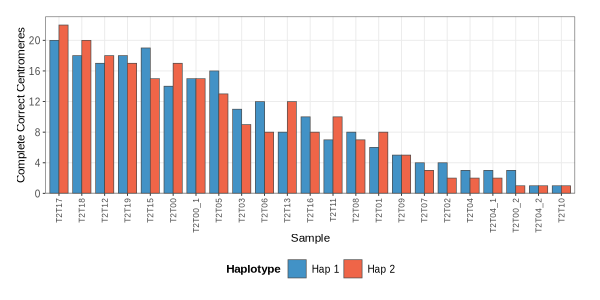

In [55]:
# Plot A: Complete correct centromeres per sample
fig4_A_cen_per_sample <- ggplot(dt_cen_per_sample, aes(x = sample, y = n_complete_cens, fill = haplotype)) +
    geom_col(position = position_dodge2(preserve = "single", padding = 0), width = 0.8, colour = "grey30", linewidth = 0.2) +
    scale_fill_manual(values = col_haplotype, name = "Haplotype") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05)), breaks = seq(0, 24, 4)) +
    labs(
        x = "Sample",
        y = "Complete Correct Centromeres"
    ) +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 5),
        legend.position = "bottom"
    )

ggsave("../../doc/figures/fig4_A_cen_per_sample.png", fig4_A_cen_per_sample, width = sizes["A1"], height = sizes["A2"])
ggsave("../../doc/figures/fig4_A_cen_per_sample.pdf", fig4_A_cen_per_sample, width = sizes["A1"], height = sizes["A2"])

options(repr.plot.width = sizes["A1"], repr.plot.height = sizes["A2"])
fig4_A_cen_per_sample

## B: Complete correct centromeres per chromosome

Bar plot showing the number of complete correct centromeres for each chromosome across all samples, split by haplotype.

In [56]:
# Count complete correct centromeres per chromosome and haplotype
dt_cen_per_chr <- dt_cen %>%
    count(chromosome, haplotype, name = "n_complete_cens") %>%
    arrange(chromosome)

head(dt_cen_per_chr)

chromosome,haplotype,n_complete_cens
<fct>,<chr>,<int>
chr1,Hap 1,8
chr1,Hap 2,9
chr2,Hap 1,22
chr2,Hap 2,22
chr3,Hap 1,1
chr3,Hap 2,6


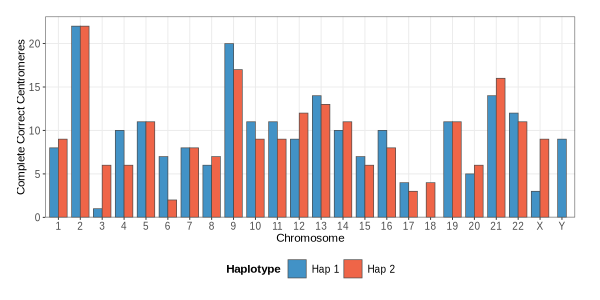

In [57]:
# Plot B: Complete correct centromeres per chromosome
fig4_B_cen_per_chr <- ggplot(dt_cen_per_chr, aes(x = chromosome, y = n_complete_cens, fill = haplotype)) +
    geom_col(position = position_dodge2(preserve = "single", padding = 0), width = 0.8, colour = "grey30", linewidth = 0.2) +
    scale_fill_manual(values = col_haplotype, name = "Haplotype") +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    labs(
        x = "Chromosome",
        y = "Complete Correct Centromeres"
    ) +
    theme(
        legend.position = "bottom"
    )

ggsave("../../doc/figures/fig4_B_cen_per_chr.png", fig4_B_cen_per_chr, width = sizes["B1"], height = sizes["B2"])
ggsave("../../doc/figures/fig4_B_cen_per_chr.pdf", fig4_B_cen_per_chr, width = sizes["B1"], height = sizes["B2"])

options(repr.plot.width = sizes["B1"], repr.plot.height = sizes["B2"])
fig4_B_cen_per_chr